# GAT Session Recommendation Results Analysis

This notebook loads archived runs from `results-1/` for summaries and compares them with **SR-GNN** / **TAGNN** paper table numbers. **`results-2/`** holds exports after the GAT architectural revision—the **main** literature comparison is **Revised architecture (results-2) vs SR-GNN / TAGNN (paper)** immediately after the `results-1` aggregation cells. **`results-1` → `results-2`** drift is in an **appendix**.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results-1"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"
RESULTS_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.3f}".format


def bold_numeric_column_max(table, precision=3):
    """Return a Styler that bolds the maximum value in each numeric column."""
    numeric_columns = table.select_dtypes(include="number").columns

    def highlight(column):
        if column.name not in numeric_columns or column.empty:
            return [""] * len(column)
        max_value = column.max(skipna=True)
        return ["font-weight: bold" if value == max_value else "" for value in column]

    return table.style.apply(highlight, axis=0).format(precision=precision)

In [2]:
# Literature values from the TAGNN paper table supplied in the prompt.
# Columns are ordered with Yoochoose first, then Diginetica, to match the current analysis focus.
tagnn_baselines = pd.DataFrame([
    ["POP", 6.71, 1.65, 0.89, 0.20],
    ["S-POP", 30.44, 18.35, 21.06, 13.68],
    ["Item-KNN", 51.60, 21.81, 35.75, 11.57],
    ["BPR-MF", 31.31, 12.08, 5.24, 1.98],
    ["FPMC", 45.62, 15.01, 26.53, 6.95],
    ["GRU4REC", 60.64, 22.89, 29.45, 8.33],
    ["NARM", 68.32, 28.63, 49.70, 16.17],
    ["STAMP", 68.74, 29.67, 45.64, 14.32],
    ["SR-GNN", 70.57, 30.94, 50.73, 17.59],
    ["TAGNN", 71.02, 31.12, 51.31, 18.03],
], columns=["method", "yoochoose_1_64_precision@20", "yoochoose_1_64_mrr@20", "diginetica_precision@20", "diginetica_mrr@20"])

sr_reference = {
    ("Yoochoose 1/64", "Precision@20"): 70.57,
    ("Yoochoose 1/64", "MRR@20"): 30.94,
    ("Diginetica", "Precision@20"): 50.73,
    ("Diginetica", "MRR@20"): 17.59,
}
tag_reference = {
    ("Yoochoose 1/64", "Precision@20"): 71.02,
    ("Yoochoose 1/64", "MRR@20"): 31.12,
    ("Diginetica", "Precision@20"): 51.31,
    ("Diginetica", "MRR@20"): 18.03,
}

# The main paper-style table is displayed later with the GAT rows appended.

In [3]:
sr_results = pd.read_csv(RESULTS_DIR / "gat_sr_gnn_results.csv").assign(model="GAT-SR-GNN")
tag_results = pd.read_csv(RESULTS_DIR / "gat_tagnn_results.csv").assign(model="GAT-TAGNN")
model_summary = pd.concat([sr_results, tag_results], ignore_index=True)
model_summary = model_summary[[
    "model", "dataset", "test_precision@20", "test_mrr@20", "test_loss", "best_epoch",
    "best_validation_precision@20", "best_validation_mrr@20", "train_examples",
    "validation_examples", "test_examples", "num_items", "checkpoint_path",
]]
model_summary.to_csv(RESULTS_DIR / "model_summary.csv", index=False)

# Readable paper-style table: original TAGNN comparison table plus the two completed GAT runs.
gat_rows = []
for model_name in ["GAT-SR-GNN", "GAT-TAGNN"]:
    model_rows = model_summary[model_summary["model"] == model_name].set_index("dataset")
    gat_rows.append({
        "method": model_name,
        "yoochoose_1_64_precision@20": model_rows.loc["Yoochoose 1/64", "test_precision@20"],
        "yoochoose_1_64_mrr@20": model_rows.loc["Yoochoose 1/64", "test_mrr@20"],
        "diginetica_precision@20": model_rows.loc["Diginetica", "test_precision@20"],
        "diginetica_mrr@20": model_rows.loc["Diginetica", "test_mrr@20"],
    })
paper_comparison_with_gat = pd.concat([tagnn_baselines, pd.DataFrame(gat_rows)], ignore_index=True)
paper_comparison_with_gat = paper_comparison_with_gat[[
    "method",
    "yoochoose_1_64_precision@20",
    "yoochoose_1_64_mrr@20",
    "diginetica_precision@20",
    "diginetica_mrr@20",
]]
paper_comparison_with_gat.to_csv(RESULTS_DIR / "paper_comparison_with_gat.csv", index=False)

plot_comparison = paper_comparison_with_gat[
    paper_comparison_with_gat["method"].isin(["SR-GNN", "TAGNN", "GAT-SR-GNN", "GAT-TAGNN"])
].copy()

# Compact machine-readable deltas for plots and saved CSVs. These are intentionally not displayed.
comparison_rows = []
for row in model_summary.to_dict("records"):
    if row["model"] == "GAT-SR-GNN":
        reference_method = "SR-GNN"
        reference = sr_reference
    else:
        reference_method = "TAGNN"
        reference = tag_reference
    for metric, column in [("Precision@20", "test_precision@20"), ("MRR@20", "test_mrr@20")]:
        value = row[column]
        reference_value = reference[(row["dataset"], metric)]
        comparison_rows.append({
            "model": row["model"],
            "reference_method": reference_method,
            "dataset": row["dataset"],
            "metric": metric,
            "model_value": value,
            "reference_value": reference_value,
            "delta": value - reference_value,
            "relative_delta_%": 100.0 * (value - reference_value) / reference_value,
        })
literature_comparison = pd.DataFrame(comparison_rows)
literature_comparison.to_csv(RESULTS_DIR / "literature_comparison.csv", index=False)

head_to_head = model_summary.pivot(index="dataset", columns="model", values=["test_precision@20", "test_mrr@20"])
head_to_head = pd.DataFrame({
    "dataset": head_to_head.index,
    "gat_sr_gnn_precision@20": head_to_head[("test_precision@20", "GAT-SR-GNN")].values,
    "gat_tagnn_precision@20": head_to_head[("test_precision@20", "GAT-TAGNN")].values,
    "precision_delta_tagnn_minus_sr": head_to_head[("test_precision@20", "GAT-TAGNN")].values - head_to_head[("test_precision@20", "GAT-SR-GNN")].values,
    "gat_sr_gnn_mrr@20": head_to_head[("test_mrr@20", "GAT-SR-GNN")].values,
    "gat_tagnn_mrr@20": head_to_head[("test_mrr@20", "GAT-TAGNN")].values,
    "mrr_delta_tagnn_minus_sr": head_to_head[("test_mrr@20", "GAT-TAGNN")].values - head_to_head[("test_mrr@20", "GAT-SR-GNN")].values,
})
head_to_head.to_csv(RESULTS_DIR / "gat_head_to_head.csv", index=False)

display(bold_numeric_column_max(paper_comparison_with_gat))

,method,yoochoose_1_64_precision@20,yoochoose_1_64_mrr@20,diginetica_precision@20,diginetica_mrr@20
0,POP,6.710,1.650,0.890,0.200
1,S-POP,30.440,18.350,21.060,13.680
2,Item-KNN,51.600,21.810,35.750,11.570
3,BPR-MF,31.310,12.080,5.240,1.980
4,FPMC,45.620,15.010,26.530,6.950
5,GRU4REC,60.640,22.890,29.450,8.330
6,NARM,68.320,28.630,49.700,16.170
7,STAMP,68.740,29.670,45.640,14.320
8,SR-GNN,70.570,30.940,50.730,17.590
9,TAGNN,71.020,31.120,51.310,18.030


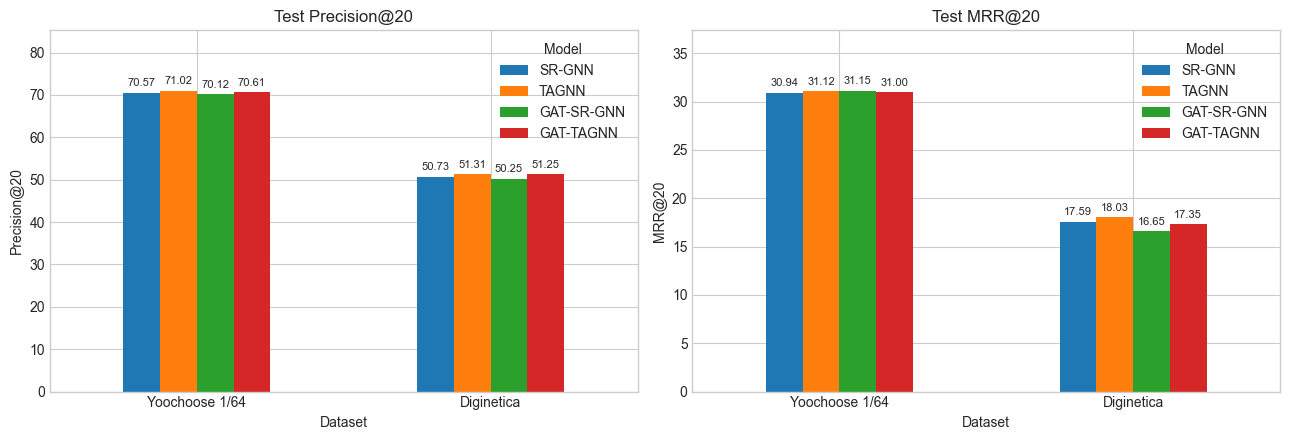

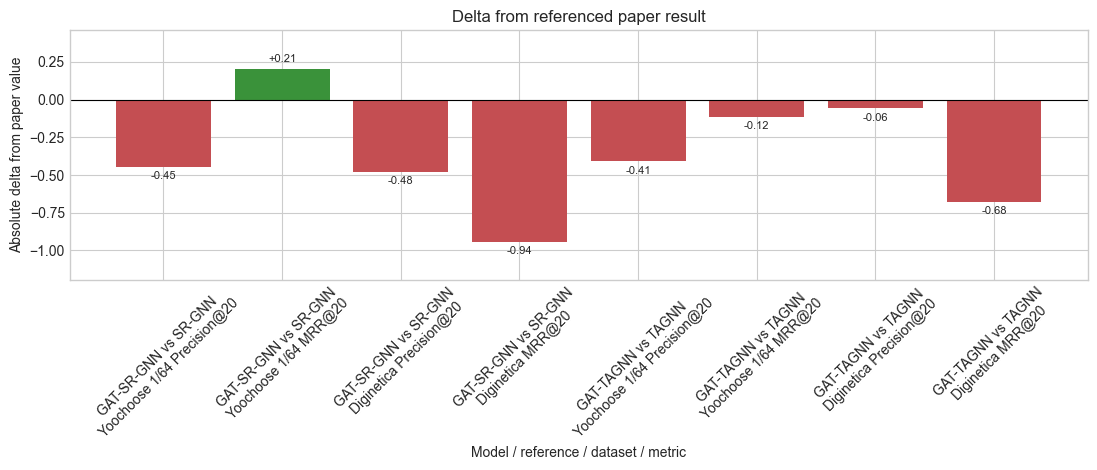

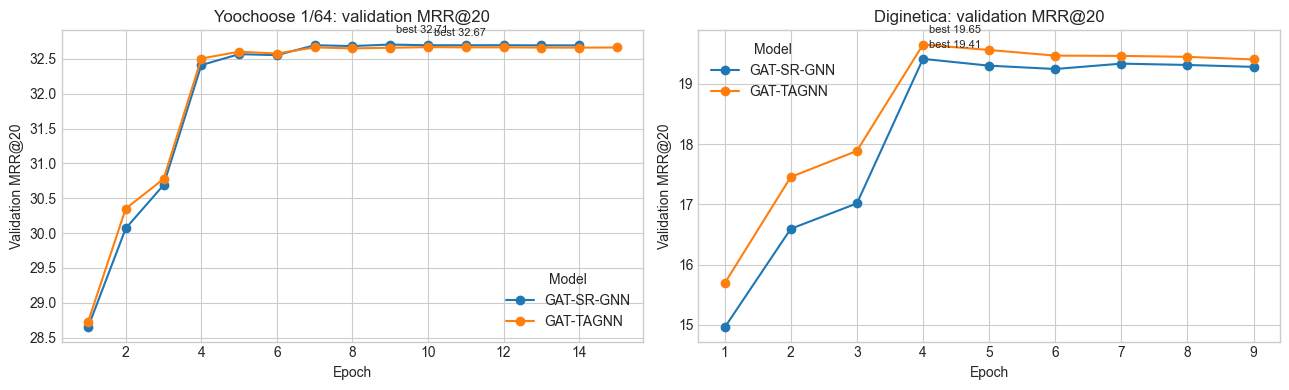

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_methods = ["SR-GNN", "TAGNN", "GAT-SR-GNN", "GAT-TAGNN"]
metric_specs = [
    (
        "Test Precision@20",
        ["yoochoose_1_64_precision@20", "diginetica_precision@20"],
        ["Yoochoose 1/64", "Diginetica"],
    ),
    (
        "Test MRR@20",
        ["yoochoose_1_64_mrr@20", "diginetica_mrr@20"],
        ["Yoochoose 1/64", "Diginetica"],
    ),
]
for ax, (title, columns, dataset_labels) in zip(axes, metric_specs):
    plot_data = plot_comparison.set_index("method").loc[plot_methods, columns].T
    plot_data.index = dataset_labels
    plot_data.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(title)
    ax.set_xlabel("Dataset")
    ax.set_ylabel(title.replace("Test ", ""))
    ax.legend(title="Model")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
    ax.margins(y=0.2)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "model_summary.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.8))
delta_plot = literature_comparison.assign(
    label=lambda df: df["model"] + " vs " + df["reference_method"] + "\n" + df["dataset"] + " " + df["metric"]
)
bars = ax.bar(
    delta_plot["label"],
    delta_plot["delta"],
    color=["#3a923a" if x >= 0 else "#c44e52" for x in delta_plot["delta"]],
)
ax.axhline(0, color="black", linewidth=0.8)
ax.bar_label(bars, fmt="%+.2f", padding=3, fontsize=8)
ax.set_ylabel("Absolute delta from paper value")
ax.set_xlabel("Model / reference / dataset / metric")
ax.set_title("Delta from referenced paper result")
ax.tick_params(axis="x", rotation=45)
ax.margins(y=0.22)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "literature_delta.png", dpi=180, bbox_inches="tight")
plt.show()

histories = []
for model, filename in [("GAT-SR-GNN", "gat_sr_gnn_history.csv"), ("GAT-TAGNN", "gat_tagnn_history.csv")]:
    histories.append(pd.read_csv(RESULTS_DIR / filename).assign(model=model))
history = pd.concat(histories, ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=False)
for dataset, ax in zip(["Yoochoose 1/64", "Diginetica"], axes):
    subset = history[history["dataset"] == dataset]
    for model, group in subset.groupby("model"):
        ax.plot(group["epoch"], group["validation_mrr@20"], marker="o", label=model)
        best_row = group.loc[group["validation_mrr@20"].idxmax()]
        ax.annotate(
            f"best {best_row['validation_mrr@20']:.2f}",
            xy=(best_row["epoch"], best_row["validation_mrr@20"]),
            xytext=(4, 8),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set_title(f"{dataset}: validation MRR@20")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MRR@20")
    ax.legend(title="Model")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

## Revised architecture (`results-2`) vs SR-GNN / TAGNN (paper)

This is the **primary** comparison relative to published baselines: revised **GAT-SR-GNN** / **GAT-TAGNN** (CSV under `results-2/`; TAGNN placeholders until rerun) evaluated on **`Precision@20`** and **`MRR@20`**, using the **`tagnn_baselines`** table for reference lines. **`GAT-SR-GNN`** is compared against published **SR-GNN** metrics; **`GAT-TAGNN`** against published **TAGNN** metrics—the same **`sr_reference` / `tag_reference`** maps as earlier cells, backed by **`results-2`** runs instead of `results-1`. **Run-to-run evolution** (`results-1` vs `results-2`) stays in the **appendix**.


Paper-format table + revised-GAT rows (results-2/ metrics where present)


,method,yoochoose_1_64_precision@20,yoochoose_1_64_mrr@20,diginetica_precision@20,diginetica_mrr@20
0,POP,6.710,1.650,0.890,0.200
1,S-POP,30.440,18.350,21.060,13.680
2,Item-KNN,51.600,21.810,35.750,11.570
3,BPR-MF,31.310,12.080,5.240,1.980
4,FPMC,45.620,15.010,26.530,6.950
5,GRU4REC,60.640,22.890,29.450,8.330
6,NARM,68.320,28.630,49.700,16.170
7,STAMP,68.740,29.670,45.640,14.320
8,SR-GNN,70.570,30.940,50.730,17.590
9,TAGNN,71.020,31.120,51.310,18.030



Deltas vs paper SR-GNN / TAGNN table (finite revised rows only)


,model,reference_method,dataset,metric,model_value,reference_value,delta,relative_delta_%
0,GAT-SR-GNN,SR-GNN,Yoochoose 1/64,Precision@20,68.729,70.570,-1.841,-2.609
1,GAT-SR-GNN,SR-GNN,Yoochoose 1/64,MRR@20,30.355,30.940,-0.585,-1.891
2,GAT-SR-GNN,SR-GNN,Diginetica,Precision@20,50.629,50.730,-0.101,-0.198
3,GAT-SR-GNN,SR-GNN,Diginetica,MRR@20,16.725,17.590,-0.865,-4.917



(No GAT-TAGNN rows in deltas until results-2/`gat_tagnn_results.csv` exists.)


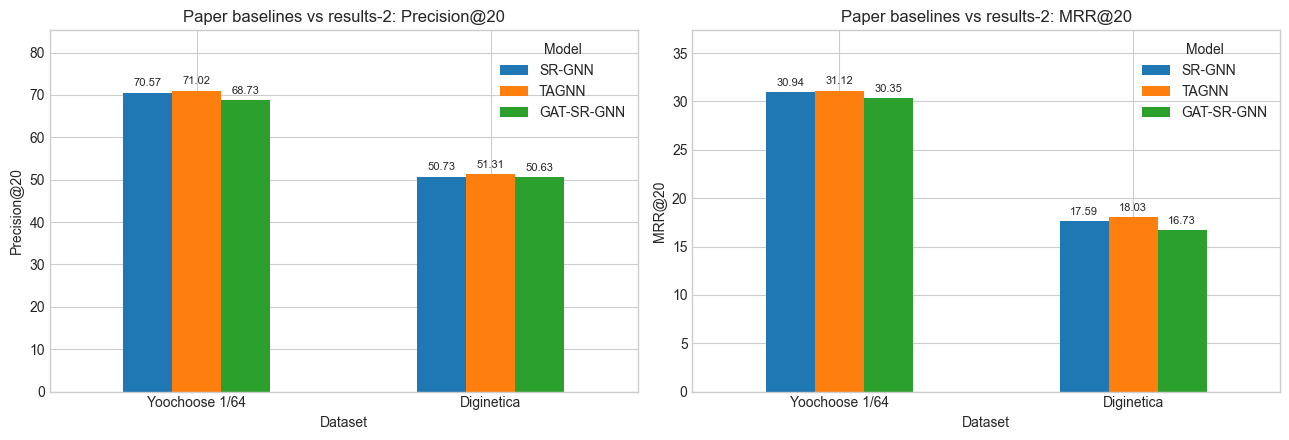

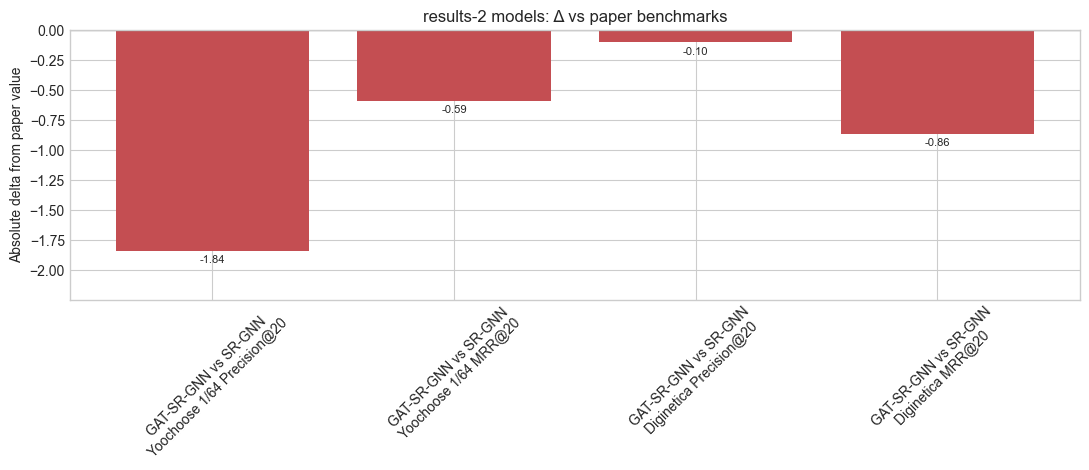

In [5]:
from IPython.display import display

RESULTS_REVISION = PROJECT_ROOT / "results-2"
RESULTS_REVISION.mkdir(exist_ok=True)

sr_rev_csv = RESULTS_REVISION / "gat_sr_gnn_results.csv"
tag_rev_csv = RESULTS_REVISION / "gat_tagnn_results.csv"
if not sr_rev_csv.is_file():
    raise FileNotFoundError(f"Expect revised GAT-SR-GNN results at `{sr_rev_csv}` for the literature comparison.")

sr_rev_rows = pd.read_csv(sr_rev_csv).assign(model="GAT-SR-GNN")
rev_ds_order = sr_rev_rows["dataset"].tolist()


def revision_tag_placeholder(reference_columns):
    rows = []
    for ds in rev_ds_order:
        row = {col: pd.NA for col in reference_columns if col != "dataset"}
        row["dataset"] = ds
        row["checkpoint_path"] = "pending: add results-2/gat_tagnn_results.csv after rerun"
        rows.append(row)
    return pd.DataFrame(rows, columns=reference_columns)


if tag_rev_csv.is_file():
    tag_rev_rows = pd.read_csv(tag_rev_csv).assign(model="GAT-TAGNN")
else:
    tag_rev_rows = revision_tag_placeholder(list(sr_rev_rows.columns)).assign(model="GAT-TAGNN")

model_summary_rev2 = pd.concat([sr_rev_rows, tag_rev_rows], ignore_index=True)
model_summary_rev2 = model_summary_rev2[[
    "model", "dataset", "test_precision@20", "test_mrr@20", "test_loss", "best_epoch",
    "best_validation_precision@20", "best_validation_mrr@20", "train_examples",
    "validation_examples", "test_examples", "num_items", "checkpoint_path",
]]
model_summary_rev2.to_csv(RESULTS_REVISION / "model_summary_rev2.csv", index=False)

gat_rows_rev2 = []
for model_name in ["GAT-SR-GNN", "GAT-TAGNN"]:
    model_rows = model_summary_rev2[model_summary_rev2["model"] == model_name].set_index("dataset")
    gat_rows_rev2.append({
        "method": model_name,
        "yoochoose_1_64_precision@20": model_rows.loc["Yoochoose 1/64", "test_precision@20"],
        "yoochoose_1_64_mrr@20": model_rows.loc["Yoochoose 1/64", "test_mrr@20"],
        "diginetica_precision@20": model_rows.loc["Diginetica", "test_precision@20"],
        "diginetica_mrr@20": model_rows.loc["Diginetica", "test_mrr@20"],
    })

paper_comparison_rev2 = pd.concat([tagnn_baselines, pd.DataFrame(gat_rows_rev2)], ignore_index=True)
paper_comparison_rev2 = paper_comparison_rev2[[
    "method",
    "yoochoose_1_64_precision@20",
    "yoochoose_1_64_mrr@20",
    "diginetica_precision@20",
    "diginetica_mrr@20",
]]
paper_comparison_rev2.to_csv(RESULTS_REVISION / "paper_comparison_with_gat_rev2.csv", index=False)

plot_comparison_rev2_base = paper_comparison_rev2[
    paper_comparison_rev2["method"].isin(["SR-GNN", "TAGNN", "GAT-SR-GNN", "GAT-TAGNN"])
].copy()
_tagn_rev = plot_comparison_rev2_base[plot_comparison_rev2_base["method"] == "GAT-TAGNN"].iloc[0]
_metric_cols_rev2 = ["yoochoose_1_64_precision@20", "yoochoose_1_64_mrr@20", "diginetica_precision@20", "diginetica_mrr@20"]
_tagn_nan = pd.isna(_tagn_rev[_metric_cols_rev2]).any()
methods_bar_rev2 = ["SR-GNN", "TAGNN", "GAT-SR-GNN"] + ([] if _tagn_nan else ["GAT-TAGNN"])
plot_comparison_rev2 = plot_comparison_rev2_base[plot_comparison_rev2_base["method"].isin(methods_bar_rev2)].copy()

comparison_rows_rev2 = []
for row in model_summary_rev2.to_dict("records"):
    if pd.isna(row["test_precision@20"]) or pd.isna(row["test_mrr@20"]):
        continue
    if row["model"] == "GAT-SR-GNN":
        reference_method = "SR-GNN"
        reference = sr_reference
    else:
        reference_method = "TAGNN"
        reference = tag_reference
    for metric, column in [("Precision@20", "test_precision@20"), ("MRR@20", "test_mrr@20")]:
        value = row[column]
        rv = reference[(row["dataset"], metric)]
        comparison_rows_rev2.append({
            "model": row["model"],
            "reference_method": reference_method,
            "dataset": row["dataset"],
            "metric": metric,
            "model_value": value,
            "reference_value": rv,
            "delta": value - rv,
            "relative_delta_%": 100.0 * (value - rv) / rv,
        })

literature_comparison_rev2 = pd.DataFrame(comparison_rows_rev2)
literature_comparison_rev2.to_csv(RESULTS_REVISION / "literature_comparison_rev2.csv", index=False)

print("Paper-format table + revised-GAT rows (results-2/ metrics where present)")
display(bold_numeric_column_max(paper_comparison_rev2))

print("\nDeltas vs paper SR-GNN / TAGNN table (finite revised rows only)")
if literature_comparison_rev2.empty:
    print("No finite revised test metrics parsed (unexpected if `gat_sr_gnn_results.csv` was found).")
else:
    display(literature_comparison_rev2.round(6))
if not tag_rev_csv.is_file():
    print("\n(No GAT-TAGNN rows in deltas until results-2/`gat_tagnn_results.csv` exists.)")

_metric_specs_rev2 = [
    (
        "Paper baselines vs results-2: Precision@20",
        "Precision@20",
        ["yoochoose_1_64_precision@20", "diginetica_precision@20"],
        ["Yoochoose 1/64", "Diginetica"],
    ),
    (
        "Paper baselines vs results-2: MRR@20",
        "MRR@20",
        ["yoochoose_1_64_mrr@20", "diginetica_mrr@20"],
        ["Yoochoose 1/64", "Diginetica"],
    ),
]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (subtitle, ylab, columns, dataset_labels) in zip(axes, _metric_specs_rev2):
    plot_block = plot_comparison_rev2.set_index("method").loc[methods_bar_rev2, columns].T
    plot_block.index = dataset_labels
    plot_block.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(subtitle)
    ax.set_xlabel("Dataset")
    ax.set_ylabel(ylab)
    ax.legend(title="Model")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
    ax.margins(y=0.2)
fig.tight_layout()
fig.savefig(RESULTS_REVISION / "paper_compare_results2.png", dpi=180, bbox_inches="tight")
plt.show()

if not literature_comparison_rev2.empty:
    fig, ax = plt.subplots(figsize=(11, 4.8))
    delta_rev2 = literature_comparison_rev2.assign(
        label=lambda df: df["model"] + " vs " + df["reference_method"] + "\n" + df["dataset"] + " " + df["metric"]
    )
    bars = ax.bar(
        delta_rev2["label"],
        delta_rev2["delta"],
        color=["#3a923a" if x >= 0 else "#c44e52" for x in delta_rev2["delta"]],
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.bar_label(bars, fmt="%+.2f", padding=3, fontsize=8)
    ax.set_ylabel("Absolute delta from paper value")
    ax.set_title("results-2 models: Δ vs paper benchmarks")
    ax.tick_params(axis="x", rotation=45)
    ax.margins(y=0.22)
    fig.tight_layout()
    fig.savefig(RESULTS_REVISION / "literature_delta_rev2.png", dpi=180, bbox_inches="tight")
    plt.show()


## Third iteration architecture (results-3) vs SR-GNN / TAGNN (paper)

This section compares the third iteration of the GAT models (`results-3/`, which introduces the fixes for edge frequencies and explicit residual connections) against the published baselines.
Currently, only `GAT-SR-GNN` has been rerun in this iteration.

Paper-format table + results-3 GAT rows (results-3/ metrics where present)


,method,yoochoose_1_64_precision@20,yoochoose_1_64_mrr@20,diginetica_precision@20,diginetica_mrr@20
0,POP,6.710,1.650,0.890,0.200
1,S-POP,30.440,18.350,21.060,13.680
2,Item-KNN,51.600,21.810,35.750,11.570
3,BPR-MF,31.310,12.080,5.240,1.980
4,FPMC,45.620,15.010,26.530,6.950
5,GRU4REC,60.640,22.890,29.450,8.330
6,NARM,68.320,28.630,49.700,16.170
7,STAMP,68.740,29.670,45.640,14.320
8,SR-GNN,70.570,30.940,50.730,17.590
9,TAGNN,71.020,31.120,51.310,18.030



Deltas vs paper SR-GNN / TAGNN table (finite results-3 rows only)


,model,reference_method,dataset,metric,model_value,reference_value,delta,relative_delta_%
0,GAT-SR-GNN,SR-GNN,Yoochoose 1/64,Precision@20,68.942,70.570,-1.628,-2.307
1,GAT-SR-GNN,SR-GNN,Yoochoose 1/64,MRR@20,30.563,30.940,-0.377,-1.220
2,GAT-SR-GNN,SR-GNN,Diginetica,Precision@20,50.736,50.730,0.006,0.012
3,GAT-SR-GNN,SR-GNN,Diginetica,MRR@20,16.855,17.590,-0.735,-4.178



(No GAT-TAGNN rows in deltas until results-3/`gat_tagnn_results.csv` exists.)


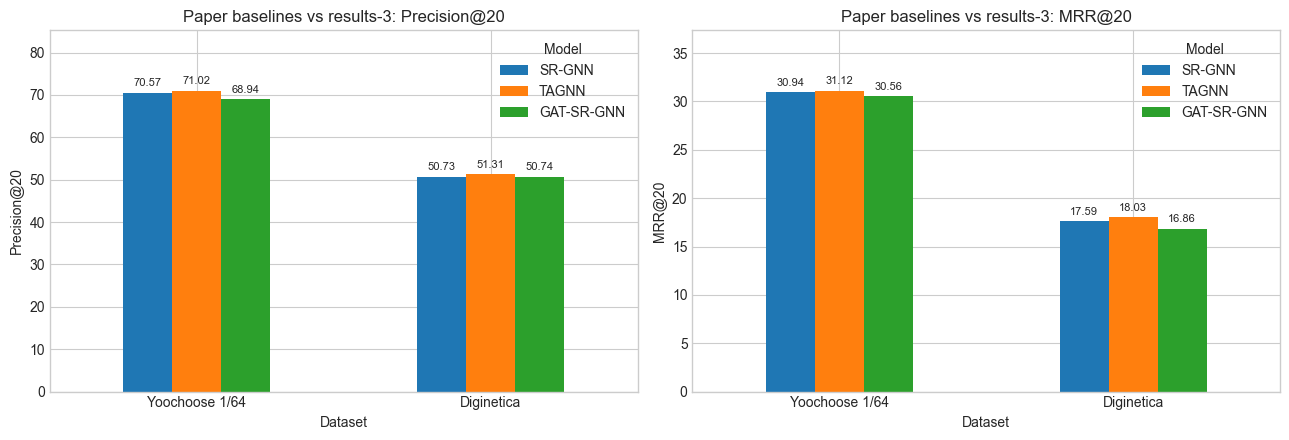

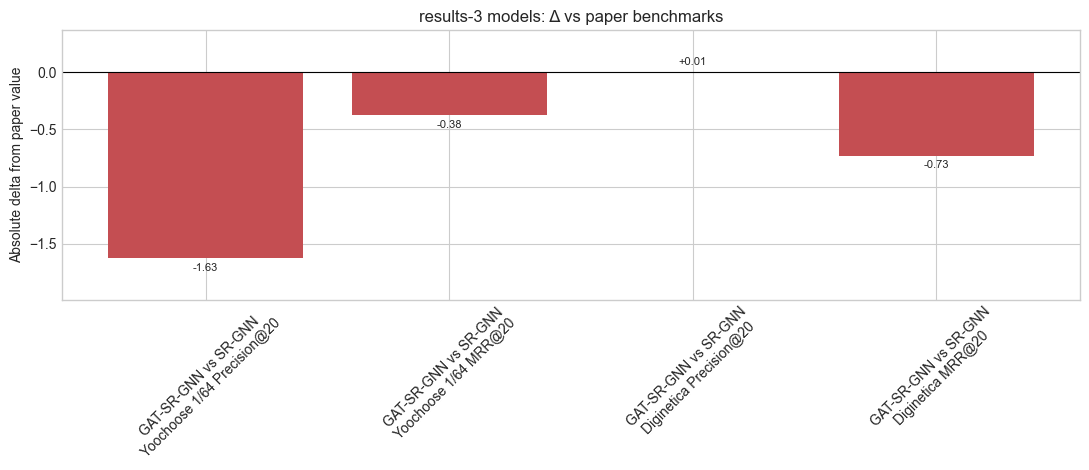

In [6]:
from IPython.display import display

RESULTS_ITERATION_3 = PROJECT_ROOT / "results-3"
RESULTS_ITERATION_3.mkdir(exist_ok=True)

sr_res3_csv = RESULTS_ITERATION_3 / "gat_sr_gnn_results.csv"
tag_res3_csv = RESULTS_ITERATION_3 / "gat_tagnn_results.csv"
if not sr_res3_csv.is_file():
    print(f"Expect revised GAT-SR-GNN results at `{sr_res3_csv}`.")

if sr_res3_csv.is_file():
    sr_res3_rows = pd.read_csv(sr_res3_csv).assign(model="GAT-SR-GNN")
    res3_ds_order = sr_res3_rows["dataset"].tolist()

    def res3_tag_placeholder(reference_columns):
        rows = []
        for ds in res3_ds_order:
            row = {col: pd.NA for col in reference_columns if col != "dataset"}
            row["dataset"] = ds
            row["checkpoint_path"] = "pending: add results-3/gat_tagnn_results.csv after rerun"
            rows.append(row)
        return pd.DataFrame(rows, columns=reference_columns)

    if tag_res3_csv.is_file():
        tag_res3_rows = pd.read_csv(tag_res3_csv).assign(model="GAT-TAGNN")
    else:
        tag_res3_rows = res3_tag_placeholder(list(sr_res3_rows.columns)).assign(model="GAT-TAGNN")

    model_summary_res3 = pd.concat([sr_res3_rows, tag_res3_rows], ignore_index=True)
    model_summary_res3 = model_summary_res3[[
        "model", "dataset", "test_precision@20", "test_mrr@20", "test_loss", "best_epoch",
        "best_validation_precision@20", "best_validation_mrr@20", "train_examples",
        "validation_examples", "test_examples", "num_items", "checkpoint_path",
    ]]
    model_summary_res3.to_csv(RESULTS_ITERATION_3 / "model_summary_res3.csv", index=False)

    gat_rows_res3 = []
    for model_name in ["GAT-SR-GNN", "GAT-TAGNN"]:
        model_rows = model_summary_res3[model_summary_res3["model"] == model_name].set_index("dataset")
        gat_rows_res3.append({
            "method": model_name,
            "yoochoose_1_64_precision@20": model_rows.loc["Yoochoose 1/64", "test_precision@20"],
            "yoochoose_1_64_mrr@20": model_rows.loc["Yoochoose 1/64", "test_mrr@20"],
            "diginetica_precision@20": model_rows.loc["Diginetica", "test_precision@20"],
            "diginetica_mrr@20": model_rows.loc["Diginetica", "test_mrr@20"],
        })

    paper_comparison_res3 = pd.concat([tagnn_baselines, pd.DataFrame(gat_rows_res3)], ignore_index=True)
    paper_comparison_res3 = paper_comparison_res3[[
        "method",
        "yoochoose_1_64_precision@20",
        "yoochoose_1_64_mrr@20",
        "diginetica_precision@20",
        "diginetica_mrr@20",
    ]]
    paper_comparison_res3.to_csv(RESULTS_ITERATION_3 / "paper_comparison_with_gat_res3.csv", index=False)

    plot_comparison_res3_base = paper_comparison_res3[
        paper_comparison_res3["method"].isin(["SR-GNN", "TAGNN", "GAT-SR-GNN", "GAT-TAGNN"])
    ].copy()
    _tagn_res3 = plot_comparison_res3_base[plot_comparison_res3_base["method"] == "GAT-TAGNN"].iloc[0]
    _metric_cols_res3 = ["yoochoose_1_64_precision@20", "yoochoose_1_64_mrr@20", "diginetica_precision@20", "diginetica_mrr@20"]
    _tagn_nan_res3 = pd.isna(_tagn_res3[_metric_cols_res3]).any()
    methods_bar_res3 = ["SR-GNN", "TAGNN", "GAT-SR-GNN"] + ([] if _tagn_nan_res3 else ["GAT-TAGNN"])
    plot_comparison_res3 = plot_comparison_res3_base[plot_comparison_res3_base["method"].isin(methods_bar_res3)].copy()

    comparison_rows_res3 = []
    for row in model_summary_res3.to_dict("records"):
        if pd.isna(row["test_precision@20"]) or pd.isna(row["test_mrr@20"]):
            continue
        if row["model"] == "GAT-SR-GNN":
            reference_method = "SR-GNN"
            reference = sr_reference
        else:
            reference_method = "TAGNN"
            reference = tag_reference
        for metric, column in [("Precision@20", "test_precision@20"), ("MRR@20", "test_mrr@20")]:
            value = row[column]
            rv = reference[(row["dataset"], metric)]
            comparison_rows_res3.append({
                "model": row["model"],
                "reference_method": reference_method,
                "dataset": row["dataset"],
                "metric": metric,
                "model_value": value,
                "reference_value": rv,
                "delta": value - rv,
                "relative_delta_%": 100.0 * (value - rv) / rv,
            })

    literature_comparison_res3 = pd.DataFrame(comparison_rows_res3)
    literature_comparison_res3.to_csv(RESULTS_ITERATION_3 / "literature_comparison_res3.csv", index=False)

    print("Paper-format table + results-3 GAT rows (results-3/ metrics where present)")
    display(bold_numeric_column_max(paper_comparison_res3))

    print("\nDeltas vs paper SR-GNN / TAGNN table (finite results-3 rows only)")
    if literature_comparison_res3.empty:
        print("No finite test metrics parsed.")
    else:
        display(literature_comparison_res3.round(6))
    if not tag_res3_csv.is_file():
        print("\n(No GAT-TAGNN rows in deltas until results-3/`gat_tagnn_results.csv` exists.)")

    _metric_specs_res3 = [
        (
            "Paper baselines vs results-3: Precision@20",
            "Precision@20",
            ["yoochoose_1_64_precision@20", "diginetica_precision@20"],
            ["Yoochoose 1/64", "Diginetica"],
        ),
        (
            "Paper baselines vs results-3: MRR@20",
            "MRR@20",
            ["yoochoose_1_64_mrr@20", "diginetica_mrr@20"],
            ["Yoochoose 1/64", "Diginetica"],
        ),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, (subtitle, ylab, columns, dataset_labels) in zip(axes, _metric_specs_res3):
        plot_block = plot_comparison_res3.set_index("method").loc[methods_bar_res3, columns].T
        plot_block.index = dataset_labels
        plot_block.plot(kind="bar", ax=ax, rot=0)
        ax.set_title(subtitle)
        ax.set_xlabel("Dataset")
        ax.set_ylabel(ylab)
        ax.legend(title="Model")
        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
        ax.margins(y=0.2)
    fig.tight_layout()
    fig.savefig(RESULTS_ITERATION_3 / "paper_compare_results3.png", dpi=180, bbox_inches="tight")
    plt.show()

    if not literature_comparison_res3.empty:
        fig, ax = plt.subplots(figsize=(11, 4.8))
        delta_res3 = literature_comparison_res3.assign(
            label=lambda df: df["model"] + " vs " + df["reference_method"] + "\n" + df["dataset"] + " " + df["metric"]
        )
        bars = ax.bar(
            delta_res3["label"],
            delta_res3["delta"],
            color=["#3a923a" if x >= 0 else "#c44e52" for x in delta_res3["delta"]],
        )
        ax.axhline(0, color="black", linewidth=0.8)
        ax.bar_label(bars, fmt="%+.2f", padding=3, fontsize=8)
        ax.set_ylabel("Absolute delta from paper value")
        ax.set_title("results-3 models: Δ vs paper benchmarks")
        ax.tick_params(axis="x", rotation=45)
        ax.margins(y=0.22)
        fig.tight_layout()
        fig.savefig(RESULTS_ITERATION_3 / "literature_delta_res3.png", dpi=180, bbox_inches="tight")
        plt.show()


## Appendix: run evolution `results-2` → `results-3`

This section tracks how metrics moved between the second iteration (`results-2/`) and the third iteration (`results-3/`).

GAT-SR-GNN: test metrics (results-2 vs results-3)


,model,dataset,test_precision@20_results-2,test_precision@20_results-3,test_mrr@20_results-2,test_mrr@20_results-3,Δ_test_precision@20,Δ_test_mrr@20
0,GAT-SR-GNN,Diginetica,50.629,50.736,16.725,16.855,0.107,0.130
1,GAT-SR-GNN,Yoochoose 1/64,68.729,68.942,30.355,30.563,0.213,0.208



GAT-TAGNN: results-2 vs results-3


,model,dataset,test_precision@20_results-2,test_precision@20_results-3,test_mrr@20_results-2,test_mrr@20_results-3,Δ_test_precision@20,Δ_test_mrr@20
0,GAT-TAGNN,Diginetica,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,GAT-TAGNN,Yoochoose 1/64,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


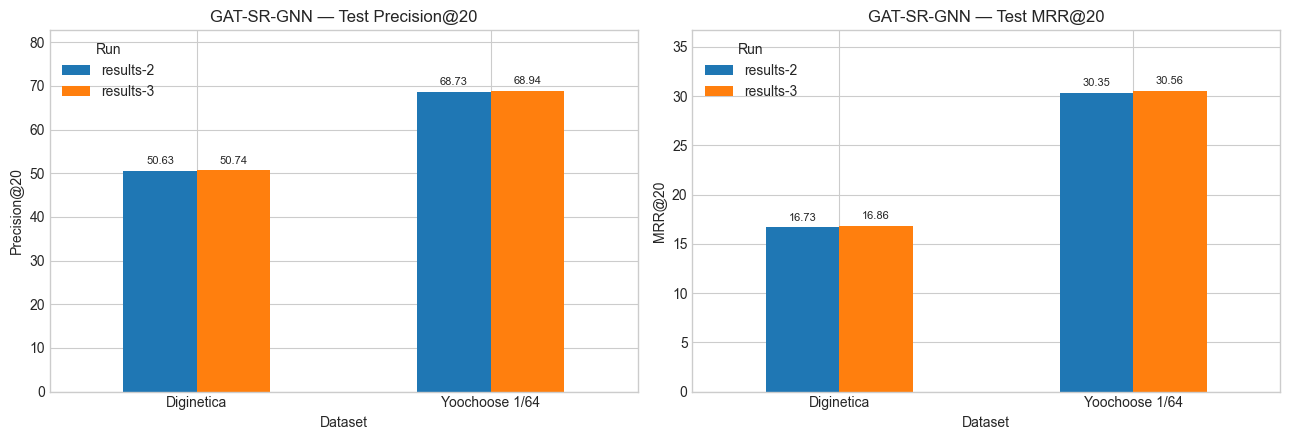

In [7]:
from IPython.display import display

RESULTS_REVISION = PROJECT_ROOT / "results-2"
RESULTS_ITERATION_3 = PROJECT_ROOT / "results-3"

sr_rev_csv = RESULTS_REVISION / "gat_sr_gnn_results.csv"
tag_rev_csv = RESULTS_REVISION / "gat_tagnn_results.csv"
sr_res3_csv = RESULTS_ITERATION_3 / "gat_sr_gnn_results.csv"
tag_res3_csv = RESULTS_ITERATION_3 / "gat_tagnn_results.csv"

if sr_rev_csv.is_file() and sr_res3_csv.is_file():
    sr_rev = pd.read_csv(sr_rev_csv)
    sr_res3 = pd.read_csv(sr_res3_csv)

    datasets_order = sr_res3["dataset"].tolist()

    def revision_placeholder(reference_columns):
        rows = []
        for ds in datasets_order:
            row = {col: pd.NA for col in reference_columns if col != "dataset"}
            row["dataset"] = ds
            row["checkpoint_path"] = "pending"
            rows.append(row)
        return pd.DataFrame(rows, columns=reference_columns)

    tag_rev = pd.read_csv(tag_rev_csv) if tag_rev_csv.is_file() else revision_placeholder(list(sr_rev.columns))
    tag_res3 = pd.read_csv(tag_res3_csv) if tag_res3_csv.is_file() else revision_placeholder(list(sr_rev.columns))

    def build_metric_compare_res3(title, baseline_df, revision_df):
        metrics = ["test_precision@20", "test_mrr@20"]
        b = baseline_df.set_index("dataset")[metrics].rename(
            columns={c: f"{c}_results-2" for c in metrics}
        )
        r = revision_df.set_index("dataset")[metrics].rename(
            columns={c: f"{c}_results-3" for c in metrics}
        )
        merged = b.join(r, how="outer")
        merged[f"Δ_test_precision@20"] = merged["test_precision@20_results-3"] - merged["test_precision@20_results-2"]
        merged[f"Δ_test_mrr@20"] = merged["test_mrr@20_results-3"] - merged["test_mrr@20_results-2"]
        out = merged.reset_index()
        out.insert(0, "model", title)
        return out

    compare_sr_res3 = build_metric_compare_res3("GAT-SR-GNN", sr_rev, sr_res3)
    compare_tag_res3 = build_metric_compare_res3("GAT-TAGNN", tag_rev, tag_res3)

    sr_style_cols_res3 = [
        "test_precision@20_results-2",
        "test_precision@20_results-3",
        "test_mrr@20_results-2",
        "test_mrr@20_results-3",
    ]
    delta_cols_res3 = ["Δ_test_precision@20", "Δ_test_mrr@20"]

    print("GAT-SR-GNN: test metrics (results-2 vs results-3)")
    display(bold_numeric_column_max(compare_sr_res3[["model", "dataset", *sr_style_cols_res3, *delta_cols_res3]]))

    print("\nGAT-TAGNN: results-2 vs results-3")
    display(compare_tag_res3[["model", "dataset", *sr_style_cols_res3, *delta_cols_res3]])
    
    _sr_plot_metrics_res3 = [
        (
            "Test Precision@20",
            ["test_precision@20_results-2", "test_precision@20_results-3"],
        ),
        (
            "Test MRR@20",
            ["test_mrr@20_results-2", "test_mrr@20_results-3"],
        ),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, (title, columns) in zip(axes, _sr_plot_metrics_res3):
        chunk = compare_sr_res3.set_index("dataset")[columns].rename(
            columns={columns[0]: "results-2", columns[1]: "results-3"}
        )
        chunk.plot(kind="bar", ax=ax, rot=0)
        ax.set_title(f"GAT-SR-GNN — {title}")
        ax.set_xlabel("Dataset")
        ax.set_ylabel(title.replace("Test ", ""))
        ax.legend(title="Run")
        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
        ax.margins(y=0.2)

    fig.tight_layout()
    fig.savefig(RESULTS_ITERATION_3 / "evolution_results2_to_3.png", dpi=180, bbox_inches="tight")
    plt.show()


## Current Findings (`results-1`)

The narrative below summarizes the **archived** runs in **`results-1/`** (exported before the simplified GAT change). For **comparison to SR-GNN / TAGNN paper numbers**, use the **Revised architecture (results-2) vs SR-GNN / TAGNN (paper)** section above instead.

`GAT-TAGNN` is the stronger of the two completed GAT variants on Precision@20 for both datasets. On Yoochoose 1/64 it reaches 70.61 P@20, which is 0.41 below the original TAGNN table value, and on Diginetica it reaches 51.25 P@20, only 0.06 below TAGNN. Its MRR@20 is slightly below TAGNN on both datasets.

`GAT-SR-GNN` is close to the original SR-GNN P@20 values but does not clearly beat them. The one positive literature delta is Yoochoose 1/64 MRR@20: 31.15 versus original SR-GNN's 30.94.

These comparisons are descriptive rather than a direct proof of GAT superiority because the original paper numbers were produced in their own implementations. A direct GGNN baseline under this repository's exact preprocessing and evaluation is still needed for the central GGNN-vs-GAT claim.

## Appendix: run evolution `results-1` → `results-2`

This is **secondary** to the literature comparison in *Revised architecture (results-2) vs SR-GNN / TAGNN (paper)*: it only tracks how metrics moved between the archived export folder and the post-revision runs.

Baseline (`results-1/`): checkpoints and CSVs from before the simplified GAT stack (commit `546a74b`: PyG-native `GATConv` init, trimming redundant residuals on top of `add_self_loops`, revised edge semantics, updated LR decay).

Revision (`results-2/`): only `GAT-SR-GNN` has been rerun so far. **`GAT-TAGNN`** rows show **placeholders** (numeric fields empty) until `gat_tagnn_results.csv` exists under `results-2/`.

In [8]:
from IPython.display import display

RESULTS_LEGACY = RESULTS_DIR
RESULTS_REVISION = PROJECT_ROOT / "results-2"
_required = [
    (RESULTS_LEGACY / "gat_sr_gnn_results.csv", "baseline GAT-SR-GNN"),
    (RESULTS_LEGACY / "gat_tagnn_results.csv", "baseline GAT-TAGNN"),
    (RESULTS_REVISION / "gat_sr_gnn_results.csv", "revised GAT-SR-GNN"),
]
for csv_path, label in _required:
    if not csv_path.is_file():
        raise FileNotFoundError(
            f"{label}: expected `{csv_path}`. Archive prior exports under results-1/ and copy revised runs into results-2/."
        )

sr_base = pd.read_csv(RESULTS_LEGACY / "gat_sr_gnn_results.csv")
tag_base = pd.read_csv(RESULTS_LEGACY / "gat_tagnn_results.csv")
sr_rev = pd.read_csv(RESULTS_REVISION / "gat_sr_gnn_results.csv")

datasets_order = sr_rev["dataset"].tolist()


def revision_placeholder(reference_columns):
    rows = []
    for ds in datasets_order:
        row = {col: pd.NA for col in reference_columns if col != "dataset"}
        row["dataset"] = ds
        row["checkpoint_path"] = "pending: add results-2/gat_tagnn_results.csv after rerun"
        rows.append(row)
    return pd.DataFrame(rows, columns=reference_columns)


tag_rev_path = RESULTS_REVISION / "gat_tagnn_results.csv"
tag_rev = (
    pd.read_csv(tag_rev_path)
    if tag_rev_path.is_file()
    else revision_placeholder(list(sr_rev.columns))
)


def build_metric_compare(title, baseline_df, revision_df):
    metrics = ["test_precision@20", "test_mrr@20"]
    b = baseline_df.set_index("dataset")[metrics].rename(
        columns={c: f"{c}_results-1" for c in metrics}
    )
    r = revision_df.set_index("dataset")[metrics].rename(
        columns={c: f"{c}_results-2" for c in metrics}
    )
    merged = b.join(r, how="outer")
    merged[f"Δ_test_precision@20"] = merged["test_precision@20_results-2"] - merged[
        "test_precision@20_results-1"
    ]
    merged[f"Δ_test_mrr@20"] = merged["test_mrr@20_results-2"] - merged["test_mrr@20_results-1"]
    out = merged.reset_index()
    out.insert(0, "model", title)
    return out


compare_sr = build_metric_compare("GAT-SR-GNN", sr_base, sr_rev)
compare_tag = build_metric_compare("GAT-TAGNN", tag_base, tag_rev)

sr_style_cols = [
    "test_precision@20_results-1",
    "test_precision@20_results-2",
    "test_mrr@20_results-1",
    "test_mrr@20_results-2",
]
delta_cols = ["Δ_test_precision@20", "Δ_test_mrr@20"]

print("GAT-SR-GNN: test metrics (results-1 vs results-2)")
display(bold_numeric_column_max(compare_sr[["model", "dataset", *sr_style_cols, *delta_cols]]))


print("\nGAT-TAGNN: baseline vs results-2 (plain table; Δ is NA until rerun CSV exists)")
display(compare_tag[["model", "dataset", *sr_style_cols, *delta_cols]])


if not tag_rev_path.is_file():
    print("\nGAT-TAGNN `results-2/` export (placeholder rows; same columns as training `gat_tagnn_results.csv`).")
display(tag_rev)


GAT-SR-GNN: test metrics (results-1 vs results-2)


,model,dataset,test_precision@20_results-1,test_precision@20_results-2,test_mrr@20_results-1,test_mrr@20_results-2,Δ_test_precision@20,Δ_test_mrr@20
0,GAT-SR-GNN,Diginetica,50.250,50.629,16.646,16.725,0.380,0.079
1,GAT-SR-GNN,Yoochoose 1/64,70.124,68.729,31.146,30.355,-1.395,-0.791



GAT-TAGNN: baseline vs results-2 (plain table; Δ is NA until rerun CSV exists)


,model,dataset,test_precision@20_results-1,test_precision@20_results-2,test_mrr@20_results-1,test_mrr@20_results-2,Δ_test_precision@20,Δ_test_mrr@20
0,GAT-TAGNN,Diginetica,51.252,<NA>,17.353,<NA>,<NA>,<NA>
1,GAT-TAGNN,Yoochoose 1/64,70.611,<NA>,31.004,<NA>,<NA>,<NA>



GAT-TAGNN `results-2/` export (placeholder rows; same columns as training `gat_tagnn_results.csv`).


,dataset,test_precision@20,test_mrr@20,test_loss,best_epoch,best_validation_precision@20,best_validation_mrr@20,train_examples,validation_examples,test_examples,num_items,checkpoint_path
0,Yoochoose 1/64,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pending: add results-2/gat_tagnn_results.csv a...
1,Diginetica,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pending: add results-2/gat_tagnn_results.csv a...


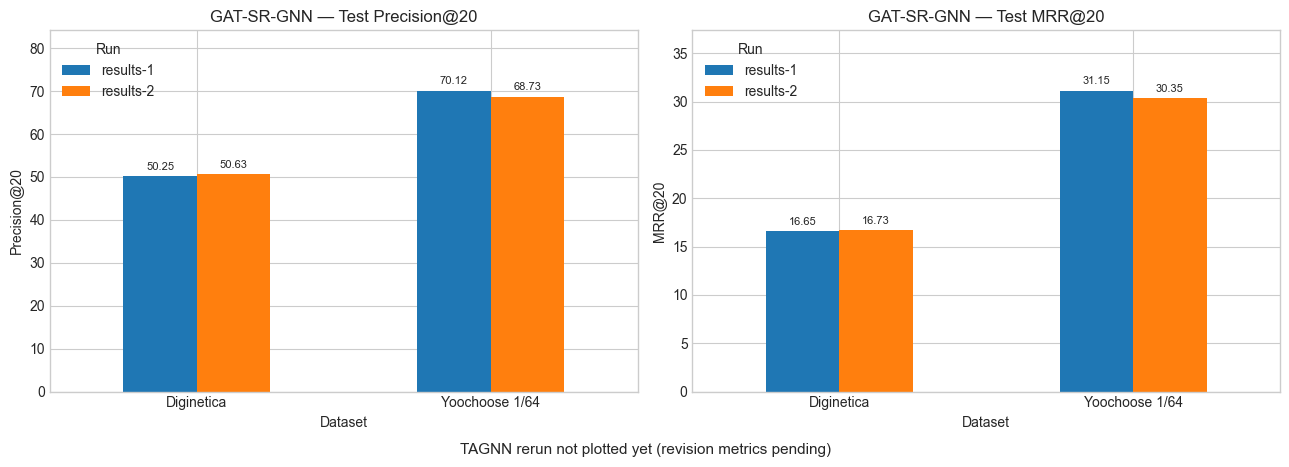

In [9]:
_sr_plot_metrics = [
    (
        "Test Precision@20",
        ["test_precision@20_results-1", "test_precision@20_results-2"],
    ),
    (
        "Test MRR@20",
        ["test_mrr@20_results-1", "test_mrr@20_results-2"],
    ),
]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (title, columns) in zip(axes, _sr_plot_metrics):
    chunk = compare_sr.set_index("dataset")[columns].rename(
        columns={columns[0]: "results-1", columns[1]: "results-2"}
    )
    chunk.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"GAT-SR-GNN — {title}")
    ax.set_xlabel("Dataset")
    ax.set_ylabel(title.replace("Test ", ""))
    ax.legend(title="Run")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
    ax.margins(y=0.2)

fig.text(0.5, -0.02, "TAGNN rerun not plotted yet (revision metrics pending)", ha="center", fontsize=11)
fig.tight_layout()
plt.show()
